In [1]:
import numpy as np
import matplotlib.pyplot as plt
from piemd import PIEMD
from base_classes import Source, DiskSource

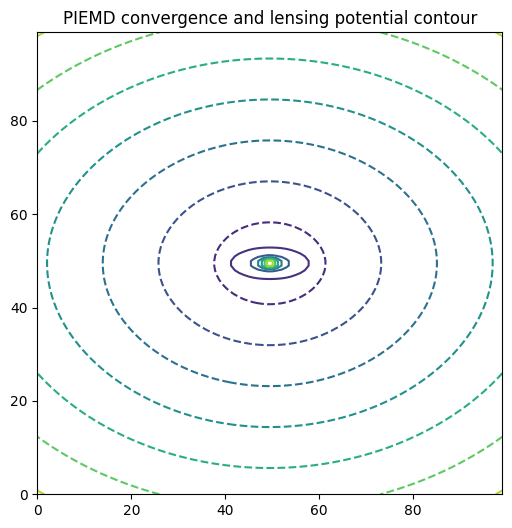

In [2]:
src = DiskSource(100, 10)
df = PIEMD(theta_E=1.0, q=0.4, s=0, phi=0)

kappa = df.get_convergence(src)
psi = df.get_potential(src)

plt.figure(figsize=(6,6))
plt.contour(kappa)
plt.contour(psi, linestyles="--")
plt.title("PIEMD convergence and lensing potential contour")
plt.show()

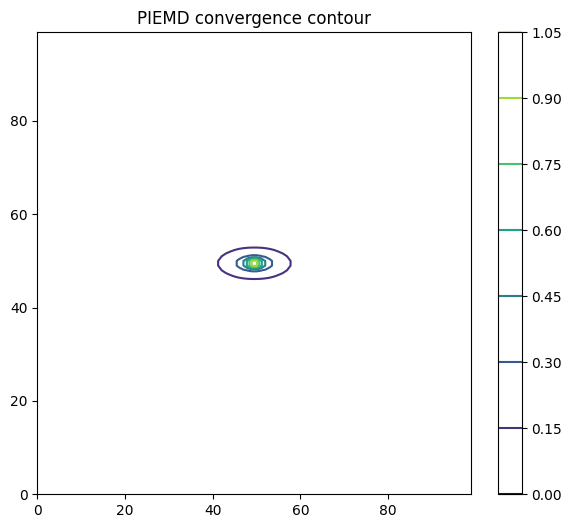

In [3]:
plt.figure(figsize=(7,6))
cbar = plt.contour(kappa)
plt.colorbar(cbar)
plt.title("PIEMD convergence contour")
plt.show()

In [35]:
src = DiskSource(50, 2)
# src.pad()
df = PIEMD(theta_E=10 ,q=1, s=0, phi=0)

img = df.get_image(src)

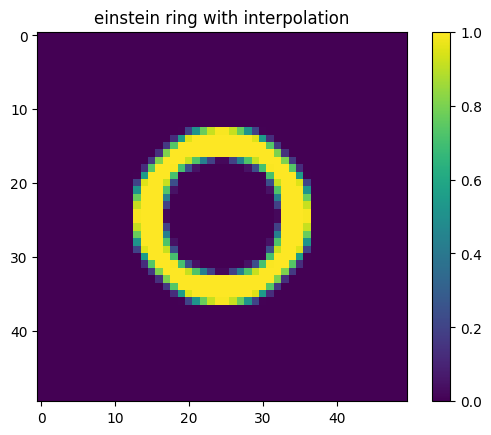

In [37]:
cbar = plt.imshow(img)
plt.colorbar(cbar)
plt.title("einstein ring with interpolation")
plt.savefig("interpolate_example.png")
plt.show()

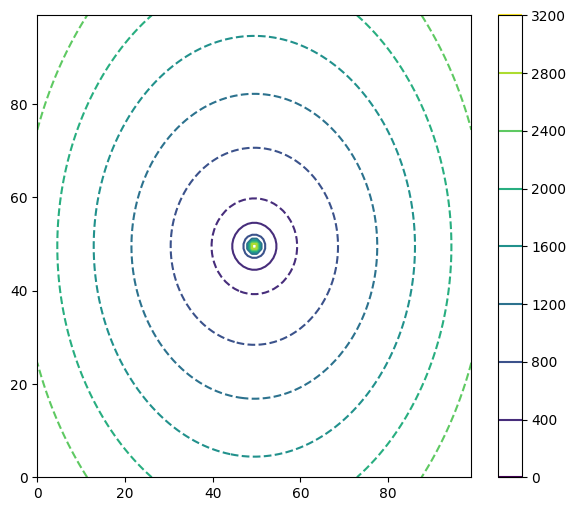

In [6]:
plt.figure(figsize=(7,6))
src = DiskSource(100, 10)
df = PIEMD(40, gamma_1=0.1, gamma_2=0)
kappa = df.get_convergence(src)
phi = df.get_potential(src)

plt.contour(kappa)
cbar = plt.contour(phi, linestyles="--")
plt.colorbar(cbar)
plt.show()

In [7]:
src = DiskSource(1001, 300)
src.pad(1000)
df = PIEMD(400, gamma_1=-0.2, gamma_2=0.1)

img = df.get_image(src)

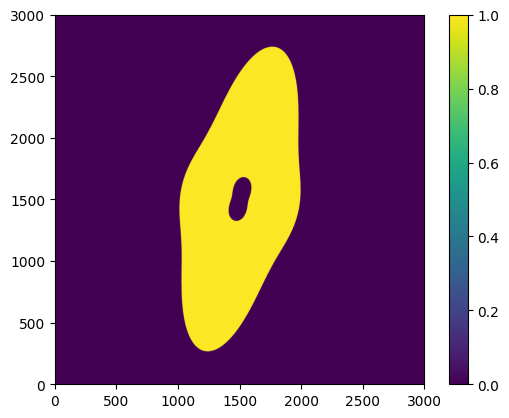

In [8]:
cbar = plt.imshow(img, origin="lower")
plt.colorbar(cbar)
plt.show()

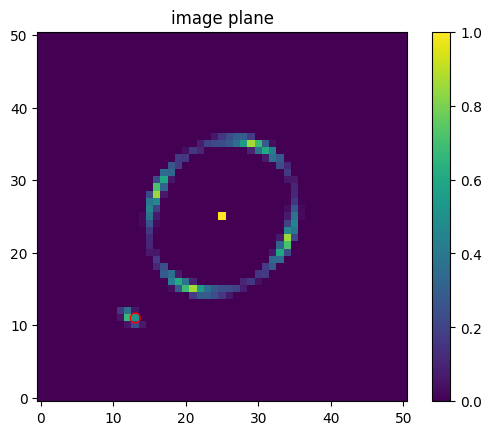

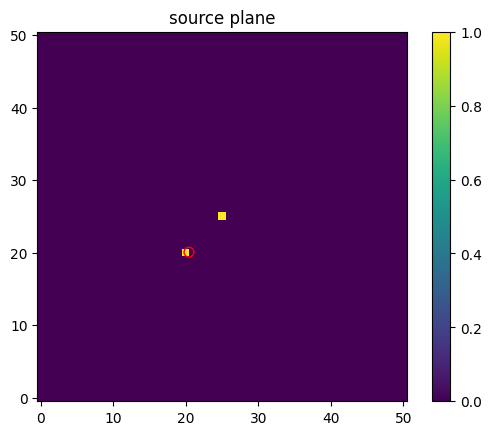

In [39]:
arr = np.zeros((51,51))
arr[25,25] = 1
arr[20,20] = 1
src = Source(arr)
df = PIEMD(10, q=0.8, s=1, gamma_1=0.01, gamma_2=0.03)

img = df.get_image(src)

cbar = plt.imshow(img, origin="lower")
plt.colorbar(cbar)

y_vec, x_vec = np.where(img > 0.5)
i = np.random.randint(x_vec.shape)
x, y = x_vec[i], y_vec[i]

r = [x,y]
beta_x, beta_y = df.map(src, r=r)
plt.scatter(x=x, y=y, facecolors='none', edgecolors='red', s=50)  # s controls size
plt.title("image plane")
plt.savefig("ray_tracing_image.png")
plt.show()

cbar = plt.imshow(arr, origin="lower")
plt.colorbar(cbar)
plt.scatter(x=beta_x, y=beta_y, facecolors="none", edgecolors="red", s=50)
plt.title("source plane")
plt.savefig("ray_tracing_source.png")
plt.show()

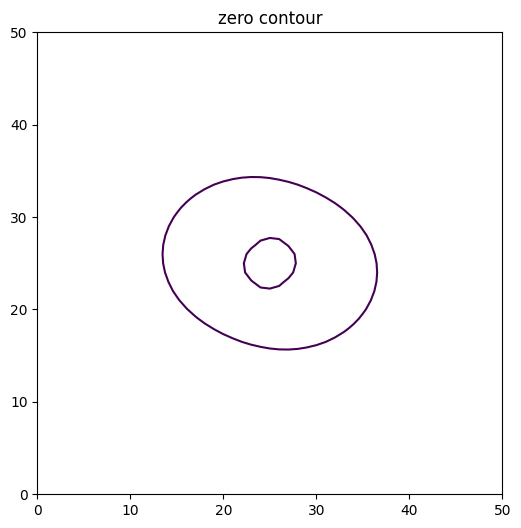

In [ ]:
a = df.get_magnification(src)

plt.figure(figsize=(6,6))
cs = plt.contour(a, levels=[0])
plt.title("zero contour")
plt.savefig("zero_contour_plot")
plt.show()

segments = cs.allsegs

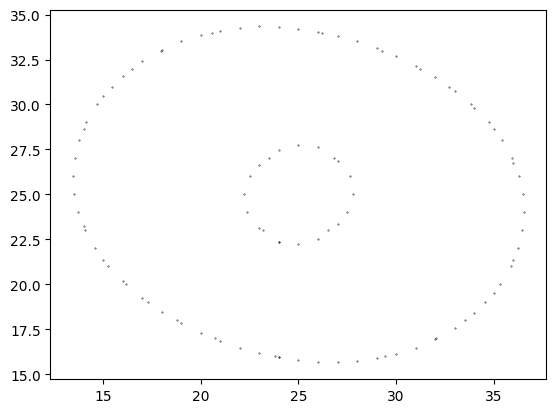

In [61]:
for s in segments[0]:
    for point in s:
        plt.scatter(x=point[0], y=point[1], c="black", s=0.1)